# *ASSIGNMENT-2: Network robustness*

In [33]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import random
from collections import defaultdict

### Functions

In [34]:
def selector(G, number_of_nodes, ranking):
    """
    Seleziona i primi number_of_nodes nodi della classifica
    che sono ancora presenti nel grafo G.
    """
    available = [n for n in ranking if n in G]
    return available[:number_of_nodes]

In [35]:
def largest_component(G):
    """
    Restituisce la componente gigante del grafo G.
    Dopo ogni attacco la rete puo' spezzarsi in piu' parti: analizziamo
    sempre la parte piu' grande ("giant component").
    """
    if G.number_of_nodes() == 0:
        return G
    components = nx.connected_components(G)
    largest = max(components, key=len)
    return G.subgraph(largest).copy()

In [36]:
def random_selector(G, number_of_nodes):
    """Seleziona number_of_nodes nodi a caso. Simula guasti casuali (random failure)."""
    nodes = list(G.nodes())
    k = min(number_of_nodes, len(nodes)) # restituisce il minimo tra number_of_nodes e il numero di nodi presenti nel grafo
    return random.sample(nodes, k)

In [37]:
def degree_ranking(G):
    degree_dict = dict(G.degree())
    ranking = sorted(degree_dict, key=degree_dict.get, reverse=True)
    return ranking

In [38]:
def pagerank_ranking(G):
    pr = nx.pagerank(G)
    ranking = sorted(pr, key=pr.get, reverse=True)
    return ranking

In [39]:
def betweenness_ranking(G, numero_nodi_campione=200, seed=42):
    """
    Calcola la betweenness una sola volta sul grafo originale,
    ordina i nodi dal valore più alto al più basso e,
    ad ogni iterazione, seleziona i primi k nodi ancora presenti.
    """
    # Evita di usare un campione più grande del numero di nodi
    numero_nodi_campione_effettivo = min(numero_nodi_campione, G.number_of_nodes())
    # Calcola la betweenness approssimata dei nodi
    betweenness = nx.betweenness_centrality(G, k=numero_nodi_campione_effettivo, seed=seed)
    # Ordina i nodi dal valore di betweenness più alto al più basso
    ranking = sorted(betweenness, key=betweenness.get, reverse=True)
    return ranking

In [40]:
def simulate_attack(G, attack_type, ranking=None, batch_size=1, use_fraction=False,
                    seed=None, verbose=True, attack_name="attacco"):
    """
    Simula un attacco alla rete.
    attack_type può essere:
    - "random"
    - "ranking"

    Se attack_type == "random", i nodi vengono scelti casualmente.
    Se attack_type == "ranking", i nodi vengono scelti usando
    la classifica passata tramite ranking.
    """
    print(f"Simulazione dell'attacco: {attack_name}")
    if seed is not None:
        random.seed(seed)
    graph_working = G.copy()
    initial_nodes = graph_working.number_of_nodes()  # numero iniziale di nodi prima dell'attacco
    if initial_nodes == 0:
        return [], []

    removed_nodes = 0
    fraction_removed = [0.0]  # frazione di nodi rimossi rispetto al numero iniziale di nodi
    # componente gigante iniziale
    largestComponent = largest_component(graph_working)
    # dimensione della componente gigante rispetto al numero iniziale di nodi
    giant_component_fraction = [largestComponent.number_of_nodes() / initial_nodes]
    collapse_printed = False
    first_iteration = True
    while graph_working.number_of_nodes() > 0:
        # Al primo giro usiamo tutto il grafo.
        # Dopo la prima rimozione lavoriamo solo sulla componente gigante.
        if first_iteration:
            current_graph = graph_working
        else:
            current_graph = largest_component(graph_working)

        if current_graph.number_of_nodes() == 0:
            break
        if use_fraction:
            # frazione dei nodi della componente corrente da rimuovere
            nodes_to_remove_count = max(1, int(batch_size * current_graph.number_of_nodes()))
        else:
            # numero fisso di nodi da rimuovere
            nodes_to_remove_count = batch_size
        nodes_to_remove_count = min(nodes_to_remove_count, current_graph.number_of_nodes())
        # selezione dei nodi da rimuovere
        if attack_type == "random":
            nodes_to_remove = random_selector(current_graph, nodes_to_remove_count)
        else:
            nodes_to_remove = selector(current_graph, nodes_to_remove_count, ranking)

        if not nodes_to_remove:
            break
        # rimozione dei nodi
        graph_working.remove_nodes_from(nodes_to_remove)
        # aggiorno il numero totale di nodi rimossi
        removed_nodes += len(nodes_to_remove)
        # dopo la rimozione troviamo la nuova componente gigante
        largestComponent = largest_component(graph_working)
        # frazione di nodi rimossi rispetto al numero iniziale di nodi
        fraction_removed.append(removed_nodes / initial_nodes)

        # dimensione attuale della componente gigante
        # rispetto al numero iniziale di nodi
        giant_component_fraction.append(largestComponent.number_of_nodes() / initial_nodes)

        # se la componente gigante è diventata più piccola
        # del 50% dei nodi iniziali
        if (verbose and not collapse_printed and largestComponent.number_of_nodes() < 0.5 * initial_nodes):
            print(
                f"COLLASSO: {attack_name} -> "
                f"GC sotto il 50% dopo {removed_nodes} nodi rimossi "
                f"({removed_nodes / initial_nodes:.1%} della rete)"
            )
            collapse_printed = True
        # dalla prossima iterazione: giant component
        first_iteration = False
    return fraction_removed, giant_component_fraction

In [41]:
def plot_results(results, title):
    plt.figure(figsize=(8,6))
    for name,(fraction_removed, giant_component_fraction) in results.items():
        plt.plot(fraction_removed, giant_component_fraction, label=name, markersize=4, linewidth=2)
    plt.xlabel("Fraction of removed nodes")
    plt.ylabel("G/N (Giant Component Size / Initial Nodes)")
    plt.title(title)
    plt.grid(alpha=.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [42]:
def run_all_attacks(G, batch_size, use_fraction, sample_size_bt=200, seed=42):
    """
    Esegue i 4 tipi di attacco:
    Random, Degree, PageRank e Betweenness.

    Le classifiche Degree, PageRank e Betweenness
    vengono calcolate una sola volta sul grafo originale.
    """

    # Crea le classifiche sul grafo originale
    deg_ranking = degree_ranking(G)
    pr_ranking = pagerank_ranking(G)
    bt_ranking = betweenness_ranking(G, numero_nodi_campione=sample_size_bt, seed=seed)

    return {
        "Random": simulate_attack(G, attack_type="random", batch_size=batch_size, use_fraction=use_fraction,
                                    seed=seed, attack_name="Random"),
        "Degree": simulate_attack(G, attack_type="ranking", ranking=deg_ranking, batch_size=batch_size,
                                    use_fraction=use_fraction, seed=seed, attack_name="Degree"),
        "PageRank": simulate_attack(G, attack_type="ranking", ranking=pr_ranking, batch_size=batch_size, 
                                    use_fraction=use_fraction, seed=seed, attack_name="PageRank"),
        "Betweenness": simulate_attack(G, attack_type="ranking", ranking=bt_ranking, batch_size=batch_size, 
                                    use_fraction=use_fraction, seed=seed, attack_name="Betweenness")
    }


In [43]:
batch_ER = 50
batch_BA = 25
batch_WS = 25

## Use small graphs to write the code

ATTACCHI GRAFO ERDOS-RENYI
Simulazione dell'attacco: Random
COLLASSO: Random -> GC sotto il 50% dopo 500 nodi rimossi (50.0% della rete)
Simulazione dell'attacco: Degree
COLLASSO: Degree -> GC sotto il 50% dopo 500 nodi rimossi (50.0% della rete)
Simulazione dell'attacco: PageRank
COLLASSO: PageRank -> GC sotto il 50% dopo 500 nodi rimossi (50.0% della rete)
Simulazione dell'attacco: Betweenness
COLLASSO: Betweenness -> GC sotto il 50% dopo 500 nodi rimossi (50.0% della rete)


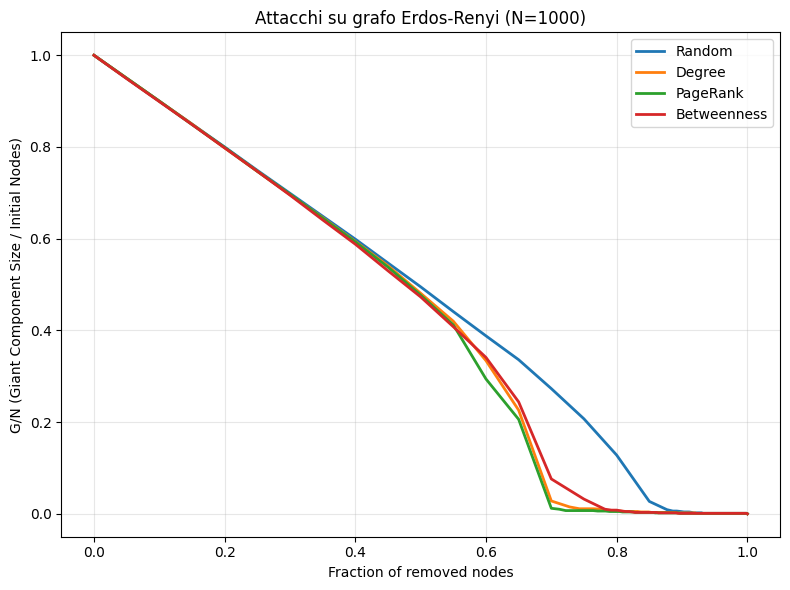

In [44]:
print("ATTACCHI GRAFO ERDOS-RENYI")
G_ER = nx.erdos_renyi_graph(1000, 0.01, seed=42)
results_ER = run_all_attacks(G_ER, batch_size=batch_ER, use_fraction=False)
plot_results(results_ER, "Attacchi su grafo Erdos-Renyi (N=1000)")

ATTACCHI GRAFO BARABASI-ALBERT
Simulazione dell'attacco: Random
COLLASSO: Random -> GC sotto il 50% dopo 500 nodi rimossi (50.0% della rete)
Simulazione dell'attacco: Degree
COLLASSO: Degree -> GC sotto il 50% dopo 375 nodi rimossi (37.5% della rete)
Simulazione dell'attacco: PageRank
COLLASSO: PageRank -> GC sotto il 50% dopo 350 nodi rimossi (35.0% della rete)
Simulazione dell'attacco: Betweenness
COLLASSO: Betweenness -> GC sotto il 50% dopo 375 nodi rimossi (37.5% della rete)


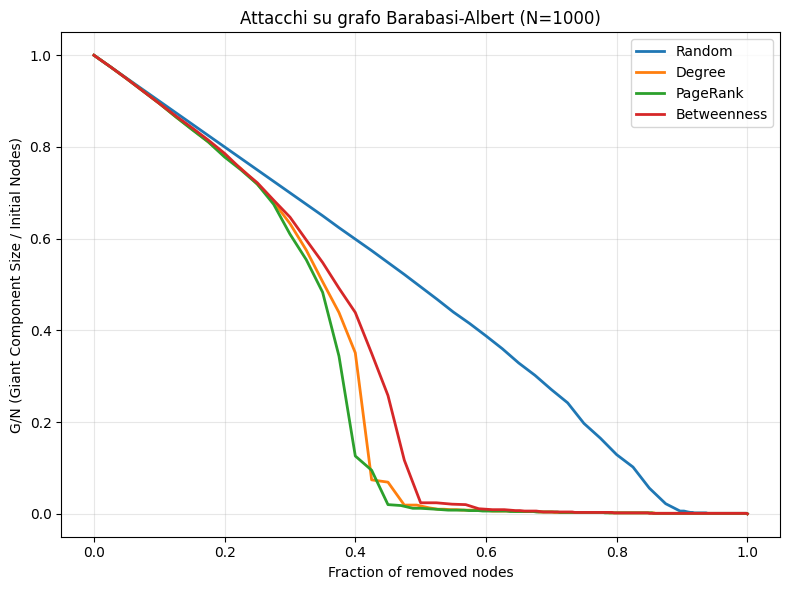

In [45]:
print("ATTACCHI GRAFO BARABASI-ALBERT")
G_BA = nx.barabasi_albert_graph(1000, 5, seed=42)
results_BA = run_all_attacks(G_BA, batch_size=batch_BA, use_fraction=False)
plot_results(results_BA, "Attacchi su grafo Barabasi-Albert (N=1000)")

ATTACCHI GRAFO WATTS-STROGATZ
Simulazione dell'attacco: Random
COLLASSO: Random -> GC sotto il 50% dopo 500 nodi rimossi (50.0% della rete)
Simulazione dell'attacco: Degree
COLLASSO: Degree -> GC sotto il 50% dopo 450 nodi rimossi (45.0% della rete)
Simulazione dell'attacco: PageRank
COLLASSO: PageRank -> GC sotto il 50% dopo 500 nodi rimossi (50.0% della rete)
Simulazione dell'attacco: Betweenness
COLLASSO: Betweenness -> GC sotto il 50% dopo 500 nodi rimossi (50.0% della rete)


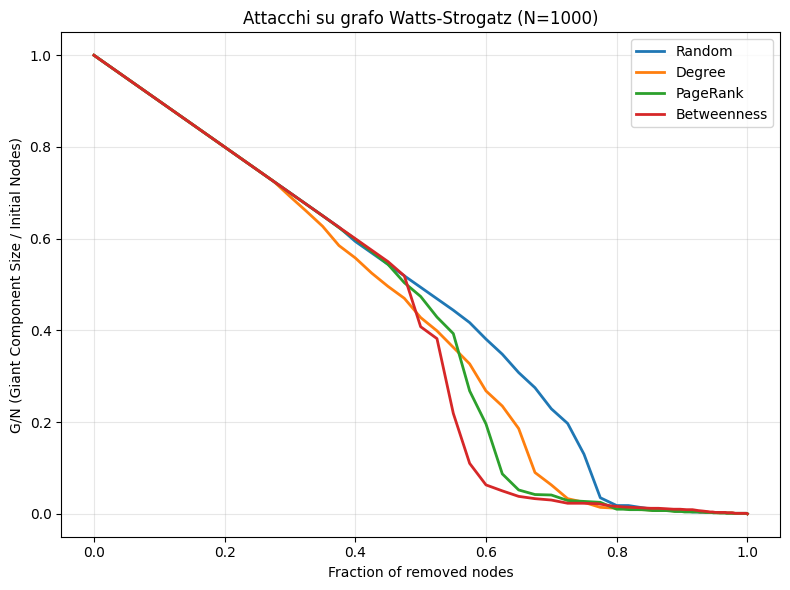

In [46]:
print("ATTACCHI GRAFO WATTS-STROGATZ")
G_WS = nx.watts_strogatz_graph(1000, 10, 0.1, seed=42)
results_WS = run_all_attacks(G_WS, batch_size=batch_WS, use_fraction=False)
plot_results(results_WS, "Attacchi su grafo Watts-Strogatz (N=1000)")

## Use your graph

In [47]:
BASE_DIR = Path().resolve().parent
DATASET_PATH = BASE_DIR / "data" / "anime_filtered.csv"
filtered = pd.read_csv(DATASET_PATH)

In [48]:
from itertools import combinations

def build_graph(filtered):
    G = nx.Graph()
    for _, row in filtered.iterrows():
        G.add_node(row["mal_id"], title=row["title"])
    for (_, a), (_, b) in combinations(filtered.iterrows(), 2):
        genres_a = set(str(a["genres"]).split("|"))
        genres_b = set(str(b["genres"]).split("|"))
        if len(genres_a & genres_b) >= 2:
            G.add_edge(a["mal_id"], b["mal_id"])
    return G

In [49]:
G_anime = build_graph(filtered)

n_nodes = G_anime.number_of_nodes()
n_edges = G_anime.number_of_edges()
density = nx.density(G_anime)
avg_degree = 2 * n_edges / n_nodes if n_nodes else 0
print(f"Grafo anime: N={n_nodes}, L={n_edges}, densita'={density:.4f}, "
      f"grado medio={avg_degree:.2f}")

Grafo anime: N=3579, L=780393, densita'=0.1219, grado medio=436.10


In [50]:
# Diagnostica frammentazione iniziale: un grafo costruito per similarita' di
# genere puo' essere NON connesso dall'inizio (tanti cluster isolati di
# anime con genere molto simile tra loro, ma poco Pesimili a tutto il resto).

n_components = nx.number_connected_components(G_anime)
GC_initial = largest_component(G_anime)
gc_fraction = GC_initial.number_of_nodes() / n_nodes if n_nodes else 0
print(f"Componenti connesse: {n_components} | "
      f"Componente gigante iniziale: {GC_initial.number_of_nodes()}/{n_nodes} "
      f"({gc_fraction:.1%} della rete)")

Componenti connesse: 728 | Componente gigante iniziale: 2838/3579 (79.3% della rete)


ATTACCHI GRAFO ANIME
Simulazione dell'attacco: Random
COLLASSO: Random -> GC sotto il 50% dopo 1048 nodi rimossi (29.3% della rete)
Simulazione dell'attacco: Degree
COLLASSO: Degree -> GC sotto il 50% dopo 940 nodi rimossi (26.3% della rete)
Simulazione dell'attacco: PageRank
COLLASSO: PageRank -> GC sotto il 50% dopo 1056 nodi rimossi (29.5% della rete)
Simulazione dell'attacco: Betweenness
COLLASSO: Betweenness -> GC sotto il 50% dopo 960 nodi rimossi (26.8% della rete)


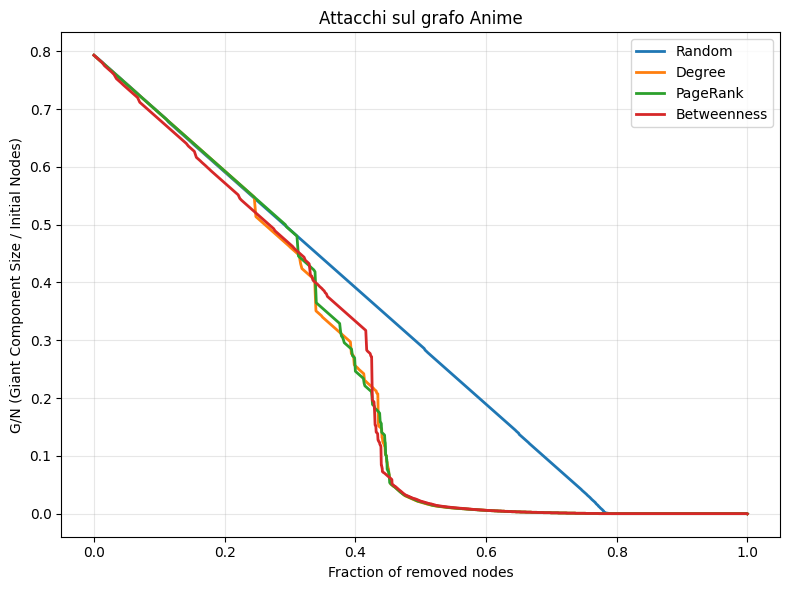

In [51]:
batch_ANIME = 0.005  # 0.5% per iterazione
print("ATTACCHI GRAFO ANIME")
results_anime = run_all_attacks(G_anime, batch_size=batch_ANIME, use_fraction=True, sample_size_bt=100)
plot_results(results_anime, "Attacchi sul grafo Anime")

In [52]:
# Discussione (punto 2 della consegna): quale strategia e' piu' dannosa?
print("Soglia (frazione di nodi rimossi) a cui G/N scende sotto 0.5 per ogni attacco:")
for name, (fraction_removed, giant_component_fraction) in results_anime.items():
    below = [xi for xi, yi in zip(fraction_removed, giant_component_fraction) if yi < 0.5]
    soglia = below[0] if below else None
    print(f"  {name}: {soglia}")

Soglia (frazione di nodi rimossi) a cui G/N scende sotto 0.5 per ogni attacco:
  Random: 0.29281922324671694
  Degree: 0.262643196423582
  PageRank: 0.2950544844928751
  Betweenness: 0.26823134953897737


## Building robustness

In [53]:
def compute_moments(G):
    """Primo e secondo momento della distribuzione del grado."""
    gradi = [grado for _, grado in G.degree()]
    primo_momento = sum(gradi) / len(gradi)
    secondo_momento = sum(grado * grado for grado in gradi) / len(gradi)
    return primo_momento, secondo_momento

In [54]:
def critical_threshold(G):
    """Soglia critica teorica fc per guasti random (formula di Molloy-Reed)."""
    primo_momento, secondo_momento = compute_moments(G)
    if secondo_momento <= primo_momento:
        return 0
    return 1 - 1 / (secondo_momento / primo_momento - 1)

In [55]:
def add_ring_degree(G, top_n=3, max_archi_per_nodo=200):
    """
    Aggiunge archi tra vicini dei nodi con grado maggiore.
    Numero di nuovi archi limitato per evitare troppe combinazioni e quindi un'esplosione del numero di archi.
    Prendo i top‑n nodi per grado e collego tra loro i loro vicini.
    """
    G_con_archi_aggiunti = G.copy()
    degree = dict(G.degree())
    top_nodes = sorted(degree, key=degree.get, reverse=True)[:top_n]
    archi_aggiunti = 0
    for node in top_nodes:
        neighbors = list(G_con_archi_aggiunti.neighbors(node))
        archi_aggiunti_nodo = 0
        for i in range(len(neighbors)):
            for j in range(i + 1, len(neighbors)):
                if archi_aggiunti_nodo >= max_archi_per_nodo:
                    break
                nodo_u = neighbors[i]
                nodo_v = neighbors[j]
                if not G_con_archi_aggiunti.has_edge(nodo_u, nodo_v):
                    G_con_archi_aggiunti.add_edge(nodo_u, nodo_v)
                    archi_aggiunti += 1
                    archi_aggiunti_nodo += 1
            if archi_aggiunti_nodo >= max_archi_per_nodo:
                break
    print(f"Ring Degree: aggiunti {archi_aggiunti} archi")
    return G_con_archi_aggiunti

In [56]:
def add_ring_betweenness(G, top_n=3, sample_size=200):
    """
    Aggiunge archi tra i vicini dei top-n nodi per betweenness stimata.
    Prendo i top‑n nodi per betweenness e collego tra loro i loro vicini.
    """
    G_new = G.copy()
    sample_size = min(sample_size, G.number_of_nodes())
    bt = nx.betweenness_centrality(G, k=sample_size, seed=42)
    top_nodes = sorted(bt, key=bt.get, reverse=True)[:top_n]
    archi_aggiunti = 0
    for node in top_nodes:
        neighbors = list(G_new.neighbors(node))
        for i in range(len(neighbors)):
            for j in range(i + 1, len(neighbors)):
                if not G_new.has_edge(neighbors[i], neighbors[j]):
                    G_new.add_edge(neighbors[i], neighbors[j])
                    archi_aggiunti += 1
    print(f"Ring Betweenness: aggiunti {archi_aggiunti} archi")
    return G_new

In [57]:
def add_edges_high_clustering(G, m=200):
    """
    Strategia di robustness basata sul clustering:
    seleziona i nodi con clustering più alto e aggiunge archi
    tra i loro vicini per aumentare la coesione locale.
    """
    G_new = G.copy()
    clustering = nx.clustering(G_new)

    # Ordina i nodi per clustering decrescente
    ordered = sorted(clustering, key=clustering.get, reverse=True)

    archi_aggiunti = 0
    for nodo in ordered:
        if archi_aggiunti >= m:
            break
        neighbors = list(G_new.neighbors(nodo))
        # Aggiungi archi tra coppie di vicini di u
        for i in range(len(neighbors)):
            for j in range(i + 1, len(neighbors)):
                if archi_aggiunti >= m:
                    break
                nodo_v = neighbors[i]
                nodo_w = neighbors[j]
                if not G_new.has_edge(nodo_v, nodo_w):
                    G_new.add_edge(nodo_v, nodo_w)
                    archi_aggiunti += 1
    print(f"High Clustering: aggiunti {archi_aggiunti} archi")
    return G_new

In [58]:
results_robustness = []

In [59]:
primo_momento, secondo_momento = compute_moments(G_anime)
fc_original = critical_threshold(G_anime)
results_robustness.append(["Original", G_anime.number_of_nodes(), G_anime.number_of_edges(), 
                           primo_momento, secondo_momento, fc_original])

In [60]:
G_degree = add_ring_degree(G_anime)
primo_momento_degree, secondo_momento_degree = compute_moments(G_degree)
fc_degree = critical_threshold(G_degree)
results_robustness.append(["Ring Degree", G_degree.number_of_nodes(), G_degree.number_of_edges(), 
                           primo_momento_degree, secondo_momento_degree, fc_degree])

Ring Degree: aggiunti 600 archi


In [61]:
grafo_betweenness = add_ring_betweenness(G_anime)
primo_momento_betweenness, secondo_momento_betweenness = compute_moments(grafo_betweenness)
fc_betweenness = critical_threshold(grafo_betweenness)
results_robustness.append(["Ring Betweenness", grafo_betweenness.number_of_nodes(), 
                           grafo_betweenness.number_of_edges(), primo_momento_betweenness, secondo_momento_betweenness, fc_betweenness])

Ring Betweenness: aggiunti 1487668 archi


In [62]:
G_clustering = add_edges_high_clustering(G_anime)
primo_momento_clustering, secondo_momento_clustering = compute_moments(G_clustering)
fc_clustering = critical_threshold(G_clustering)
results_robustness.append(["High Clustering", G_clustering.number_of_nodes(), G_clustering.number_of_edges(), 
                           primo_momento_clustering, secondo_momento_clustering, fc_clustering])

High Clustering: aggiunti 200 archi


In [63]:
df_results = pd.DataFrame(results_robustness, columns=["Graph", "N", "L", "1st moment", "2nd moment", "fc"])
print("=== Tabella soglie critiche teoriche ===")
print(df_results.to_string(index=False))

=== Tabella soglie critiche teoriche ===
           Graph    N       L  1st moment   2nd moment       fc
        Original 3579  780393  436.095557 3.516982e+05 0.998758
     Ring Degree 3579  780993  436.430847 3.522541e+05 0.998759
Ring Betweenness 3579 2268061 1267.427214 2.577432e+06 0.999508
 High Clustering 3579  780593  436.207320 3.518571e+05 0.998759
